Traza/2= 1.0601257542382987


np.float64(1.0601257542382987)

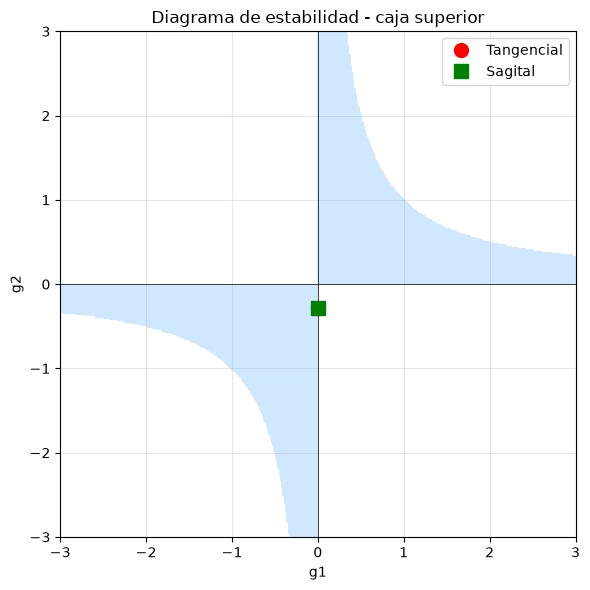

In [31]:
"""
Analisis de estabilidad de cavidad laser mediante matrices ABCD
Segmento: caja superior del diseno (espejo concavo de alta reflectividad
+ cristal KTP), usado en incidencia oblicua -> se separa en planos
tangencial y sagital debido al astigmatismo introducido por el angulo.

Parametros de entrada: distancia entre espejos (L), angulo de incidencia
sobre el espejo curvo (theta), radio de curvatura del espejo (R).
"""

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# PARAMETROS DE DISENO (editar segun el diseno real)
# ---------------------------------------------------------------
R0 = np.inf            # Radio de curvatura del espejo del ND:YAG
R1 = 0.5            # Radio de curvatura del espejo concavo [m] (dado en el diagrama: R = 10 m)
L1 = 0.5         # Distancia entre el espejo plano y el primer curvo [m]
L2 = 0.45       # Distancia entre el espejos curvos [m]
theta_deg = 5.0       # Angulo de incidencia sobre el espejo curvo [grados] (ajustar)

R2 =0.35       # Radio de curvatura del segundo espejo (plano por defecto)
theta2_deg = 0.0       # Angulo de incidencia sobre el segundo espejo (0 = normal)

# ---------------------------------------------------------------
# MATRICES ABCD BASICAS
# ---------------------------------------------------------------
def effective_radii(R, theta_deg):
    """Radios efectivos tangencial y sagital de un espejo curvo usado
    fuera de incidencia normal (formulas de Kogelnik)."""
    theta = np.radians(theta_deg)
    R_t = R * np.cos(theta)   # plano tangencial (meridional)
    R_s = R / np.cos(theta)   # plano sagital
    return R_t, R_s


def mirror_matrix(R_eff):
    """Matriz ABCD de reflexion en un espejo curvo (R_eff = inf -> plano)."""
    power = 0.0 if np.isinf(R_eff) else 2.0 / R_eff
    return np.array([[1.0, 0.0],
                      [-power, 1.0]])


def propagation_matrix(d, n=1.0):
    """Matriz ABCD de propagacion en espacio libre (o medio de indice n)."""
    return np.array([[1.0, d / n],
                      [0.0, 1.0]])


def round_trip_matrix(M0, M1, M2, L1, L2):
    """Matriz de round-trip de una cavidad lineal de 2 espejos separados L."""
    P1 = propagation_matrix(L1)
    P2 = propagation_matrix(L2)
    return M0 @ P1 @ M1@ P2 @ M2 @ P2 @ M1 @ P1 


def stability_from_trace(M):
    """Estabilidad a partir de la traza: estable si -1 < (A+D)/2 < 1."""
    A, D = M[0, 0], M[1, 1]
    m = (A + D) / 2.0
    return m, (-1.0 < m < 1.0)


# ---------------------------------------------------------------
# CALCULO PARA AMBOS PLANOS (tangencial y sagital)
# ---------------------------------------------------------------
R1_t, R1_s = effective_radii(R1, theta_deg)
R2_t, R2_s = effective_radii(R2, theta2_deg)

resultados = {}
for plano, Reff1, Reff2 in [("Tangencial", R1_t, R2_t), ("Sagital", R1_s, R2_s)]:
    M0 = mirror_matrix(Reff1)
    M1 = mirror_matrix(Reff1)
    M2 = mirror_matrix(Reff2)
    M_rt = round_trip_matrix(M0, M1, M2, L1, L2)
    m, estable_traza = stability_from_trace(M_rt)

    g1 = 1 - L1 / Reff1
    g2 = 1 - L2 / Reff2
    g1g2 = g1 * g2

    resultados[plano] = dict(
        R_eff=Reff1, g1=g1, g2=g2, g1g2=g1g2,
        m=m, estable=estable_traza
    )

# ---------------------------------------------------------------
# REPORTE
# ---------------------------------------------------------------
#print(f"Cavidad - caja superior (espejo R={R1} m, theta={theta_deg} deg, L={L} m)\n")
#for plano, r in resultados.items():
#    print(f"--- Plano {plano} ---")
#    print(f"  R efectivo del espejo curvo : {r['R_eff']:.4f} m")
#    print(f"  g1 = {r['g1']:.4f}   g2 = {r['g2']:.4f}   g1*g2 = {r['g1g2']:.4f}")
#    print(f"  0 <= g1*g2 <= 1 : {0 <= r['g1g2'] <= 1}")
#    print(f"  Estable (criterio de traza): {r['estable']}")
#    print()
print(f"Traza/2= {m}")
# ---------------------------------------------------------------
# DIAGRAMA DE ESTABILIDAD
# ---------------------------------------------------------------
g_axis = np.linspace(-3, 3, 400)
G1, G2 = np.meshgrid(g_axis, g_axis)
region = (G1 * G2 >= 0) & (G1 * G2 <= 1)

plt.figure(figsize=(6, 6))
plt.contourf(G1, G2, region, levels=[0.5, 1], colors=["#cfe8ff"])
plt.axhline(0, color="k", lw=0.5)
plt.axvline(0, color="k", lw=0.5)

for plano, marker, color in [("Tangencial", "o", "red"), ("Sagital", "s", "green")]:
    r = resultados[plano]
    plt.plot(r["g1"], r["g2"], marker, color=color, ms=10, label=plano)

plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.xlabel("g1")
plt.ylabel("g2")
plt.title("Diagrama de estabilidad - caja superior")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
m

In [24]:
m

np.float64(0.5862665130088084)